In [1]:
from src.process.graph_builder import ( NodeBuilder,MappingEdgeBuilder,GraphBuilder,build_node_schema_from_yaml,build_edge_builders_from_yaml)
import polars as pl
import yaml
from pathlib import Path

tasks_df = pl.read_parquet(Path("data/processed/tasks_processed.parquet"))
assignments_df = pl.read_parquet(Path("data/processed/assignments_processed.parquet"))
engineers_df = pl.read_parquet(Path("data/processed/engineers_processed.parquet"))
districts_df = pl.read_parquet(Path("data/processed/districts_processed.parquet"))

print(tasks_df)

shape: (5_408_941, 28)
┌─────────┬──────────┬────────────┬────────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ W6KEY   ┆ REVISION ┆ CREATEDBY  ┆ TIMECREATE ┆ … ┆ SCHEDULED ┆ ONSITETIM ┆ COMPLETIO ┆ SCHEDULEC │
│ ---     ┆ ---      ┆ ---        ┆ D          ┆   ┆ FINISH    ┆ ESTAMP    ┆ NTIMESTAM ┆ OMPLETION │
│ i64     ┆ i64      ┆ str        ┆ ---        ┆   ┆ ---       ┆ ---       ┆ P         ┆ TIME      │
│         ┆          ┆            ┆ datetime[n ┆   ┆ datetime[ ┆ datetime[ ┆ ---       ┆ ---       │
│         ┆          ┆            ┆ s]         ┆   ┆ ns]       ┆ ns]       ┆ datetime[ ┆ duration[ │
│         ┆          ┆            ┆            ┆   ┆           ┆           ┆ ns]       ┆ ns]       │
╞═════════╪══════════╪════════════╪════════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 4931378 ┆ 275      ┆ Integratio ┆ 2022-11-25 ┆ … ┆ 2023-01-0 ┆ 2023-01-0 ┆ 2023-01-0 ┆ 30m       │
│         ┆          ┆ n          ┆ 17:26:18   ┆   ┆ 6         ┆ 6  

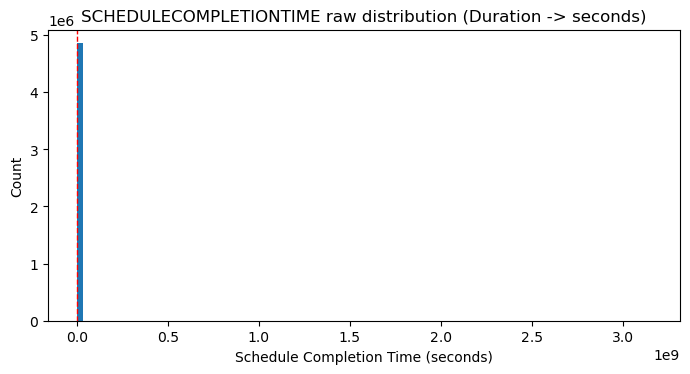

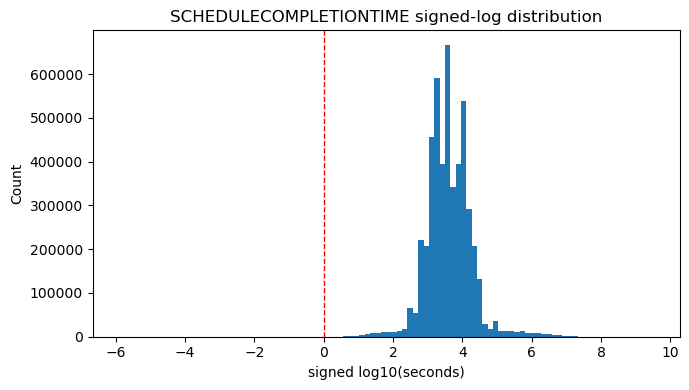

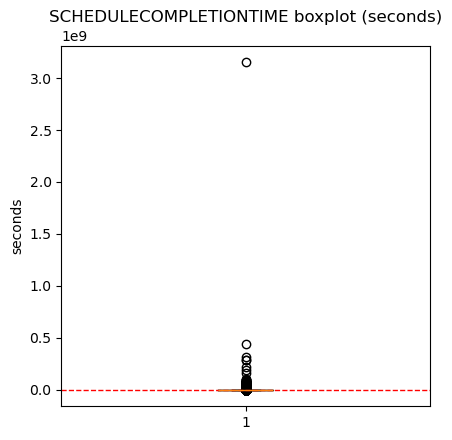

Duration(time_unit='ns')
{'min': -792240.0, 'p01': 77.0, 'p05': 600.0, 'p25': 1800.0, 'median': 3600.0, 'p75': 10800.0, 'p95': 30180.0, 'p99': 709200.0, 'max': 3155786640.0}
{'low_bound_sec': -11700.0, 'high_bound_sec': 24300.0, 'count': 370163, 'frac': 0.07626911554421867}
{'abs_days': 30.0, 'abs_seconds': 2592000.0, 'count': 19699, 'frac': 0.004058820862986208}
{'min_top': [-792240.0, -30300.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0], 'max_top': [76737600.0, 76897800.0, 77130000.0, 77130000.0, 78107400.0, 79835400.0, 88821000.0, 93849180.0, 93971520.0, 94534920.0, 94989840.0, 101694600.0, 157767120.0, 189576960.0, 220926120.0, 284004360.0, 284007600.0, 315646920.0, 441764400.0, 3155786640.0]}


In [25]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt


def _signed_log10(x: np.ndarray) -> np.ndarray:
    # signed log transform: keeps sign while compressing scale
    return np.sign(x) * np.log10(np.abs(x) + 1.0)


def diagnose_column_distribution(
    df: pl.DataFrame,
    col: str = "SCHEDULECOMPLETIONTIME",
    *,
    bins: int = 100,
    suspect_abs_days: float = 30.0,   # threshold-based outlier: |x| > N days
    top_k: int = 20,
    show: bool = True,
) -> dict:
    """
    Diagnose distribution + outliers for a single Polars column.
    - If col is Duration: convert to seconds and analyze signed distribution.
    - If col is Datetime/Date: analyze time-of-day / date distribution (NOT duration).
    - If col is numeric: treat as numeric seconds directly.

    Returns a dict with:
      - dtype, n, nulls
      - series (numpy array) used for plots
      - outlier summaries (IQR and threshold)
      - extremes (top_k min/max values)
    """

    if col not in df.columns:
        raise KeyError(f"Column '{col}' not in df. Available: {df.columns[:20]}")

    dtype = df.schema[col]
    out = {"col": col, "dtype": str(dtype)}

    # ---------------------------
    # Case A: Duration -> seconds
    # ---------------------------
    if dtype == pl.Duration:
        sec_series = (
            df.select(pl.col(col).dt.total_seconds().alias("sec"))
              .to_series()
        )
        n_total = sec_series.len()
        n_null = int(sec_series.null_count())
        out["n_total"] = int(n_total)
        out["n_null"] = int(n_null)

        s = sec_series.drop_nulls().to_numpy()
        out["n_non_null"] = int(s.size)

        if s.size == 0:
            out["note"] = "All values are null."
            return out

        # -------- stats --------
        q = np.quantile(s, [0, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 1.0])
        out["quantiles_sec"] = {
            "min": float(q[0]),
            "p01": float(q[1]),
            "p05": float(q[2]),
            "p25": float(q[3]),
            "median": float(q[4]),
            "p75": float(q[5]),
            "p95": float(q[6]),
            "p99": float(q[7]),
            "max": float(q[8]),
        }

        # -------- IQR outliers --------
        q1, q3 = q[3], q[5]
        iqr = q3 - q1
        low = q1 - 1.5 * iqr
        high = q3 + 1.5 * iqr
        iqr_mask = (s < low) | (s > high)
        out["iqr_outliers"] = {
            "low_bound_sec": float(low),
            "high_bound_sec": float(high),
            "count": int(iqr_mask.sum()),
            "frac": float(iqr_mask.mean()),
        }

        # -------- threshold outliers --------
        thr = suspect_abs_days * 24 * 3600.0
        thr_mask = np.abs(s) > thr
        out["threshold_outliers_abs_days"] = {
            "abs_days": float(suspect_abs_days),
            "abs_seconds": float(thr),
            "count": int(thr_mask.sum()),
            "frac": float(thr_mask.mean()),
        }

        # -------- extremes --------
        s_sorted = np.sort(s)
        out["extremes_sec"] = {
            "min_top": s_sorted[:top_k].astype(float).tolist(),
            "max_top": s_sorted[-top_k:].astype(float).tolist(),
        }

        # -------- plots --------
        if show:
            # Raw histogram
            plt.figure(figsize=(7, 4))
            plt.hist(s, bins=bins)
            plt.axvline(0, color="red", linestyle="--", linewidth=1)
            plt.xlabel("Schedule Completion Time (seconds)")
            plt.ylabel("Count")
            plt.title(f"{col} raw distribution (Duration -> seconds)")
            plt.tight_layout()
            plt.show()

            # Signed log histogram
            s_log = _signed_log10(s)
            plt.figure(figsize=(7, 4))
            plt.hist(s_log, bins=bins)
            plt.axvline(0, color="red", linestyle="--", linewidth=1)
            plt.xlabel("signed log10(seconds)")
            plt.ylabel("Count")
            plt.title(f"{col} signed-log distribution")
            plt.tight_layout()
            plt.show()

            # Boxplot
            plt.figure(figsize=(4.5, 4.5))
            plt.boxplot(s, vert=True, showfliers=True)
            plt.axhline(0, color="red", linestyle="--", linewidth=1)
            plt.ylabel("seconds")
            plt.title(f"{col} boxplot (seconds)")
            plt.tight_layout()
            plt.show()

        out["series_seconds"] = s  # keep for follow-up analysis
        return out

    # -----------------------------------
    # Case B: Datetime/Date -> time points
    # -----------------------------------
    if dtype in (pl.Datetime, pl.Date):
        # For time points, "distribution" usually means: date-level / hour-of-day / day-of-week
        # We avoid pretending it's a duration.
        base = df.select(pl.col(col)).drop_nulls()

        n_total = df.height
        n_null = int(df.select(pl.col(col).is_null().sum()).item())
        out["n_total_rows"] = int(n_total)
        out["n_null"] = int(n_null)
        out["n_non_null"] = int(base.height)

        if base.height == 0:
            out["note"] = "All values are null."
            return out

        if show:
            # Hour-of-day histogram (only meaningful for Datetime)
            if dtype == pl.Datetime:
                hours = base.select(pl.col(col).dt.hour().alias("hour")).to_series().to_numpy()
                plt.figure(figsize=(7, 4))
                plt.hist(hours, bins=24, range=(0, 24))
                plt.xlabel("hour of day")
                plt.ylabel("count")
                plt.title(f"{col} hour-of-day distribution")
                plt.tight_layout()
                plt.show()

            # Date histogram (bucket by date)
            dates = (
                base.select(pl.col(col).dt.date().alias("date") if dtype == pl.Datetime else pl.col(col).alias("date"))
                    .group_by("date")
                    .len()
                    .sort("date")
            )
            # Plot counts over time (line plot)
            d_pd = dates.to_pandas()
            plt.figure(figsize=(8, 4))
            plt.plot(d_pd["date"], d_pd["len"])
            plt.xlabel("date")
            plt.ylabel("count")
            plt.title(f"{col} counts by date")
            plt.tight_layout()
            plt.show()

        out["note"] = "Column is Datetime/Date. Plotted time-of-day and counts-by-date (not duration)."
        return out

    # ---------------------------
    # Case C: Numeric -> histogram
    # ---------------------------
    if dtype.is_numeric():
        s = df.select(pl.col(col)).to_series()
        out["n_total"] = int(s.len())
        out["n_null"] = int(s.null_count())
        x = s.drop_nulls().to_numpy().astype(float)
        out["n_non_null"] = int(x.size)

        if x.size == 0:
            out["note"] = "All values are null."
            return out

        q = np.quantile(x, [0, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 1.0])
        out["quantiles"] = {
            "min": float(q[0]),
            "p01": float(q[1]),
            "p05": float(q[2]),
            "p25": float(q[3]),
            "median": float(q[4]),
            "p75": float(q[5]),
            "p95": float(q[6]),
            "p99": float(q[7]),
            "max": float(q[8]),
        }

        # IQR
        q1, q3 = q[3], q[5]
        iqr = q3 - q1
        low = q1 - 1.5 * iqr
        high = q3 + 1.5 * iqr
        mask = (x < low) | (x > high)
        out["iqr_outliers"] = {
            "low_bound": float(low),
            "high_bound": float(high),
            "count": int(mask.sum()),
            "frac": float(mask.mean()),
        }

        if show:
            plt.figure(figsize=(7, 4))
            plt.hist(x, bins=bins)
            plt.axvline(0, color="red", linestyle="--", linewidth=1)
            plt.xlabel(col)
            plt.ylabel("Count")
            plt.title(f"{col} raw distribution (numeric)")
            plt.tight_layout()
            plt.show()

            x_log = _signed_log10(x)
            plt.figure(figsize=(7, 4))
            plt.hist(x_log, bins=bins)
            plt.axvline(0, color="red", linestyle="--", linewidth=1)
            plt.xlabel("signed log10(x)")
            plt.ylabel("Count")
            plt.title(f"{col} signed-log distribution (numeric)")
            plt.tight_layout()
            plt.show()

            plt.figure(figsize=(4.5, 4.5))
            plt.boxplot(x, vert=True, showfliers=True)
            plt.axhline(0, color="red", linestyle="--", linewidth=1)
            plt.ylabel(col)
            plt.title(f"{col} boxplot")
            plt.tight_layout()
            plt.show()

        out["series_numeric"] = x
        return out

    # ---------------------------
    # Unsupported types
    # ---------------------------
    raise TypeError(f"Unsupported dtype for plotting distribution: {dtype}")


# --------------------
# Example usage:
# --------------------
result = diagnose_column_distribution(tasks_df, "SCHEDULECOMPLETIONTIME", suspect_abs_days=30, top_k=20)
print(result["dtype"])
print(result.get("quantiles_sec") or result.get("quantiles"))
print(result.get("iqr_outliers"))
print(result.get("threshold_outliers_abs_days"))
print(result.get("extremes_sec"))


In [ ]:
tasks_df[["W6KEY","PRIORITY","REGION","DISTRICT","TASKTYPE","SCHEDULECOMPLETIONTIME","SCHEDULEDSTART","SCHEDULEDFINISH"]]

W6KEY,REVISION,CREATEDBY,TIMECREATED,MODIFIEDBY,TIMEMODIFIED,CALLID,TASKNUMBER,EARLYSTART,DUEDATE,LATESTART,PRIORITY,STATUS,REGION,DISTRICT,POSTCODE,OPENDATE,TASKTYPE,DURATION,NUMBEROFREQUIREDENGINEERS,CRITICAL,CITY,ISCREWTASK,SCHEDULEDSTART,SCHEDULEDFINISH,ONSITETIMESTAMP,COMPLETIONTIMESTAMP,SCHEDULECOMPLETIONTIME
i64,i64,str,datetime[ns],str,datetime[ns],str,i64,datetime[ns],datetime[ns],datetime[ns],i64,f64,f64,f64,str,datetime[ns],f64,f64,f64,f64,str,f64,datetime[ns],datetime[ns],datetime[ns],datetime[ns],duration[ns]
4931378,275,"""Integration""",2022-11-25 17:26:18,"""NETWORK SERVICE""",2023-01-15 21:37:00,"""SAP-PM510000915794""",10,2023-01-01 00:00:00,2023-10-31 23:59:00,2023-10-31 23:29:00,3,1.24131328e8,17.0,133.0,null,2022-11-25 17:26:00,1602.0,1800.0,1.0,0.0,null,-1.0,2023-01-06 11:13:00,2023-01-06 11:43:00,2023-01-06 09:09:00,2023-01-06 10:18:00,30m
4330696,297,"""Integration""",2021-11-25 05:51:27,"""NETWORK SERVICE""",2022-04-08 21:55:24,"""SAP-PM510000845290""",10,2022-01-01 00:00:00,2022-10-31 23:59:00,2022-10-31 23:29:00,3,1.24131328e8,14.0,139.0,null,2021-11-25 05:51:00,1602.0,1800.0,1.0,0.0,null,-1.0,2022-03-30 10:51:00,2022-03-30 11:26:00,2022-03-30 13:09:00,2022-03-30 14:06:00,35m
2775391,202,"""Integration""",2017-11-25 04:48:01,"""NETWORK SERVICE""",2018-07-04 22:04:45,"""SAP-PM510000545993""",10,2018-01-01 00:00:00,2018-10-31 23:59:00,2018-10-31 23:29:00,3,1.24131328e8,14.0,135.0,null,2017-11-25 04:48:00,1602.0,1800.0,1.0,0.0,null,-1.0,2018-06-25 13:43:00,2018-06-25 14:13:00,2018-06-25 13:53:00,2018-06-25 13:54:00,30m
3184154,155,"""Integration""",2018-11-25 19:11:50,"""NETWORK SERVICE""",2019-02-17 22:02:31,"""SAP-PM510000628344""",10,2019-01-01 00:00:00,2019-10-31 23:59:00,2019-10-31 23:29:00,3,1.24131328e8,17.0,128.0,null,2018-11-25 19:11:00,1602.0,1800.0,1.0,0.0,null,-1.0,2019-02-08 07:40:00,2019-02-08 08:19:00,2019-02-08 12:24:00,2019-02-08 12:43:00,39m
4934397,289,"""Integration""",2022-11-25 08:56:39,"""NETWORK SERVICE""",2023-02-04 21:55:58,"""SAP-PM510000911765""",10,2023-01-01 00:00:00,2023-10-31 23:59:00,2023-10-31 23:29:00,3,1.24131328e8,17.0,128.0,null,2022-11-25 08:56:00,1602.0,1800.0,1.0,0.0,null,-1.0,2023-01-26 14:31:00,2023-01-26 14:38:00,2023-01-26 15:28:00,2023-01-26 15:28:00,7m
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
6467395,18,"""NETWORK SERVICE""",2024-12-15 19:42:06,"""corp.se.sempra.com\ANajera2""",2024-12-16 10:31:07,"""SAP-PM520004077401""",10,2024-12-15 00:00:00,2024-12-16 00:00:00,2024-12-15 22:42:00,2,1.24153862e8,28.0,212.0,"""99999""",null,2764.0,4680.0,1.0,0.0,"""ONTARIO""",0.0,2024-12-16 10:04:32,2024-12-16 10:31:04,2024-12-16 10:04:32,2024-12-16 10:31:04,26m 32s
6636622,14,"""NETWORK SERVICE""",2025-04-02 22:45:10,"""corp.se.sempra.com\ggrajed1""",2025-04-03 14:21:17,"""SAP-PM520004180026""",10,2025-04-02 00:00:00,2025-04-03 00:00:00,2025-04-02 22:42:00,2,1.24153862e8,31.0,225.0,"""99999""",null,2764.0,4680.0,1.0,0.0,"""LOS ANGELES""",0.0,2025-04-03 09:44:48,2025-04-03 10:31:34,2025-04-03 09:44:48,2025-04-03 10:31:34,46m 46s
6620539,15,"""NETWORK SERVICE""",2025-03-24 14:37:45,"""corp.se.sempra.com\rreynos1""",2025-03-25 09:57:54,"""SAP-PM520004167608""",10,2025-03-24 00:00:00,2025-03-25 00:00:00,2025-03-24 22:42:00,2,1.24153862e8,31.0,246.0,"""99999""",null,2764.0,4680.0,1.0,0.0,"""Los Angeles""",0.0,2025-03-25 09:15:04,2025-03-25 09:57:51,2025-03-25 09:15:04,2025-03-25 09:57:51,42m 47s
